In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import re
import pandas as pd
import seaborn as sns

In [55]:
data_dir = "../output/"
runs = os.listdir(data_dir)
print(len(runs))

690


In [56]:
METRIC_PATTERNS = {
    "total_cycle": re.compile(r"total cycle =\s*(\d+)"),
    "load_cycle": re.compile(r"load cycle =\s*(\d+)"),
    "multiply_cycle": re.compile(r"multiply cycle =\s*(\d+)"),
    "merge_writeback_cycle": re.compile(r"merge and writeback cycle =\s*(\d+)"),
    "total_sram_cycle": re.compile(r"total SRAM cycle =\s*(\d+)"),
    "total_dram_cycle": re.compile(r"total DRAM cycle =\s*(\d+)"),
    "total_pe_cycle": re.compile(r"total PE cycle =\s*(\d+)"),
    "total_dram_access_a": re.compile(r"total DRAM access A =\s*(\d+)"),
    "total_dram_access_b": re.compile(r"total DRAM access B =\s*(\d+)"),
    "total_dram_access_c": re.compile(r"total DRAM access C =\s*(\d+)"),
    "hitrate": re.compile(r"hitrate =\s*([0-9eE+\-.]+)"),
    "dense_hitrate": re.compile(r"dense rate = ([\d\w.-]+)"), 
    "dense_stores": re.compile(r"dense store = ([\d\w.-]+)"), 
    "dense_stores_hit": re.compile(r"dense hit/store = ([\d\w.-]+)"),
    "dense_replaced_sparse": re.compile(r"sparse_replaced_dense: ([\d]+)"),
    "sparse_replaced_dense": re.compile(r"dense_replaced_sparse: ([\d]+)"),
}

MATRIX_PATTERNS = {
  "nnz": re.compile(r'number of non-zeros = ([\d]+)'),
  "I": re.compile(r'I = (\d+)'),
  "J": re.compile(r'J = (\d+)'),
  "K": re.compile(r'K = (\d+)'),
  "non_empty": re.compile(r'ratio of not empty ([\d.]+)'),
}

config_fields = re.compile(r'CGust(\w+)_(\d+\.\d+)MB_(\d+\.\d+)GBs_(\d+)PEs_(\d+)sbanks__([\w.-]+)_(\d)_data_(\d)_coord_(\d)\.txt')
def parse_config_from_filename(filename):
    match = config_fields.match(filename)
    if not match:
        print(filename)
    mode, sram_mb, dram_bandwidth_gbs, pes, sram_banks, matrix_name, transpose, data_bytes, coord_bytes = match.groups()
    return pd.Series({
            'mode'               : mode
           ,'sram_mb'            : sram_mb
           ,'dram_bandwidth_gbs' : dram_bandwidth_gbs
           ,'pes'                : pes
           ,'sram_banks'         : sram_banks
           ,'transpose'          : True if transpose == '1' else False
           ,'data_bytes'         : data_bytes
           ,'coord_bytes'        : coord_bytes
           ,'matrix type'        : 'dense' if 'dense' in filename else 'sparse'
           ,'matrix'             : matrix_name[:len(matrix_name)//2 - 2]
           })

def parse_runs(filenames):
    rows = []
    bad_data = []
    for file in filenames:
        with open(data_dir + file, 'r') as f:
            text = f.read()
            columns = {key:METRIC_PATTERNS[key].findall(text) for key in METRIC_PATTERNS}
            broadcast = {key:MATRIX_PATTERNS[key].search(text) for key in MATRIX_PATTERNS}

        
        min_len = min([len(columns[key]) for key in columns])
        if min_len == 0:
            bad_data.append(file)
            continue
        
        columns['file'] = [file] * min_len
        columns['testcase'] = ['CurrentCache', 'Dense', 'SeaCache', 'InnerSP', 'Sparch', 'X-cache', 'Scratchpad']
        
        data = pd.DataFrame.from_dict({key:columns[key][:min_len] for key in columns})
        for key in broadcast:
            data[key] = broadcast[key].group(1)
        rows.append(data)
    return pd.concat(rows), bad_data

In [57]:
df, bad_runs = parse_runs(runs)
print(len(bad_runs))
df.info()

107
<class 'pandas.DataFrame'>
Index: 3483 entries, 0 to 5
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   total_cycle            3483 non-null   str  
 1   load_cycle             3483 non-null   str  
 2   multiply_cycle         3483 non-null   str  
 3   merge_writeback_cycle  3483 non-null   str  
 4   total_sram_cycle       3483 non-null   str  
 5   total_dram_cycle       3483 non-null   str  
 6   total_pe_cycle         3483 non-null   str  
 7   total_dram_access_a    3483 non-null   str  
 8   total_dram_access_b    3483 non-null   str  
 9   total_dram_access_c    3483 non-null   str  
 10  hitrate                3483 non-null   str  
 11  dense_hitrate          3483 non-null   str  
 12  dense_stores           3483 non-null   str  
 13  dense_stores_hit       3483 non-null   str  
 14  dense_replaced_sparse  3483 non-null   str  
 15  sparse_replaced_dense  3483 non-null   str  
 16  fil

In [58]:
configs = df.file.apply(parse_config_from_filename)
data = pd.concat([df, configs], axis=1).reset_index(drop=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3483 entries, 0 to 3482
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   total_cycle            3483 non-null   str  
 1   load_cycle             3483 non-null   str  
 2   multiply_cycle         3483 non-null   str  
 3   merge_writeback_cycle  3483 non-null   str  
 4   total_sram_cycle       3483 non-null   str  
 5   total_dram_cycle       3483 non-null   str  
 6   total_pe_cycle         3483 non-null   str  
 7   total_dram_access_a    3483 non-null   str  
 8   total_dram_access_b    3483 non-null   str  
 9   total_dram_access_c    3483 non-null   str  
 10  hitrate                3483 non-null   str  
 11  dense_hitrate          3483 non-null   str  
 12  dense_stores           3483 non-null   str  
 13  dense_stores_hit       3483 non-null   str  
 14  dense_replaced_sparse  3483 non-null   str  
 15  sparse_replaced_dense  3483 non-null   str  
 16 

In [59]:
data.nnz

0       58983
1       58983
2       58983
3       58983
4       58983
        ...  
3478    58983
3479    58983
3480    58983
3481    58983
3482    58983
Name: nnz, Length: 3483, dtype: str

In [60]:
numeric_cols = [col for col in data.columns if 'file' not in col and 'testcase' not in col and 'mode' not in col and 'matrix' not in col]
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3483 entries, 0 to 3482
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_cycle            3483 non-null   int64  
 1   load_cycle             3483 non-null   int64  
 2   multiply_cycle         3483 non-null   int64  
 3   merge_writeback_cycle  3483 non-null   int64  
 4   total_sram_cycle       3483 non-null   int64  
 5   total_dram_cycle       3483 non-null   int64  
 6   total_pe_cycle         3483 non-null   int64  
 7   total_dram_access_a    3483 non-null   int64  
 8   total_dram_access_b    3483 non-null   int64  
 9   total_dram_access_c    3483 non-null   int64  
 10  hitrate                2903 non-null   float64
 11  dense_hitrate          2903 non-null   float64
 12  dense_stores           3483 non-null   int64  
 13  dense_stores_hit       520 non-null    float64
 14  dense_replaced_sparse  3483 non-null   int64  
 15  sparse_replaced

In [61]:
data.to_csv('../output/parsed_data.csv')

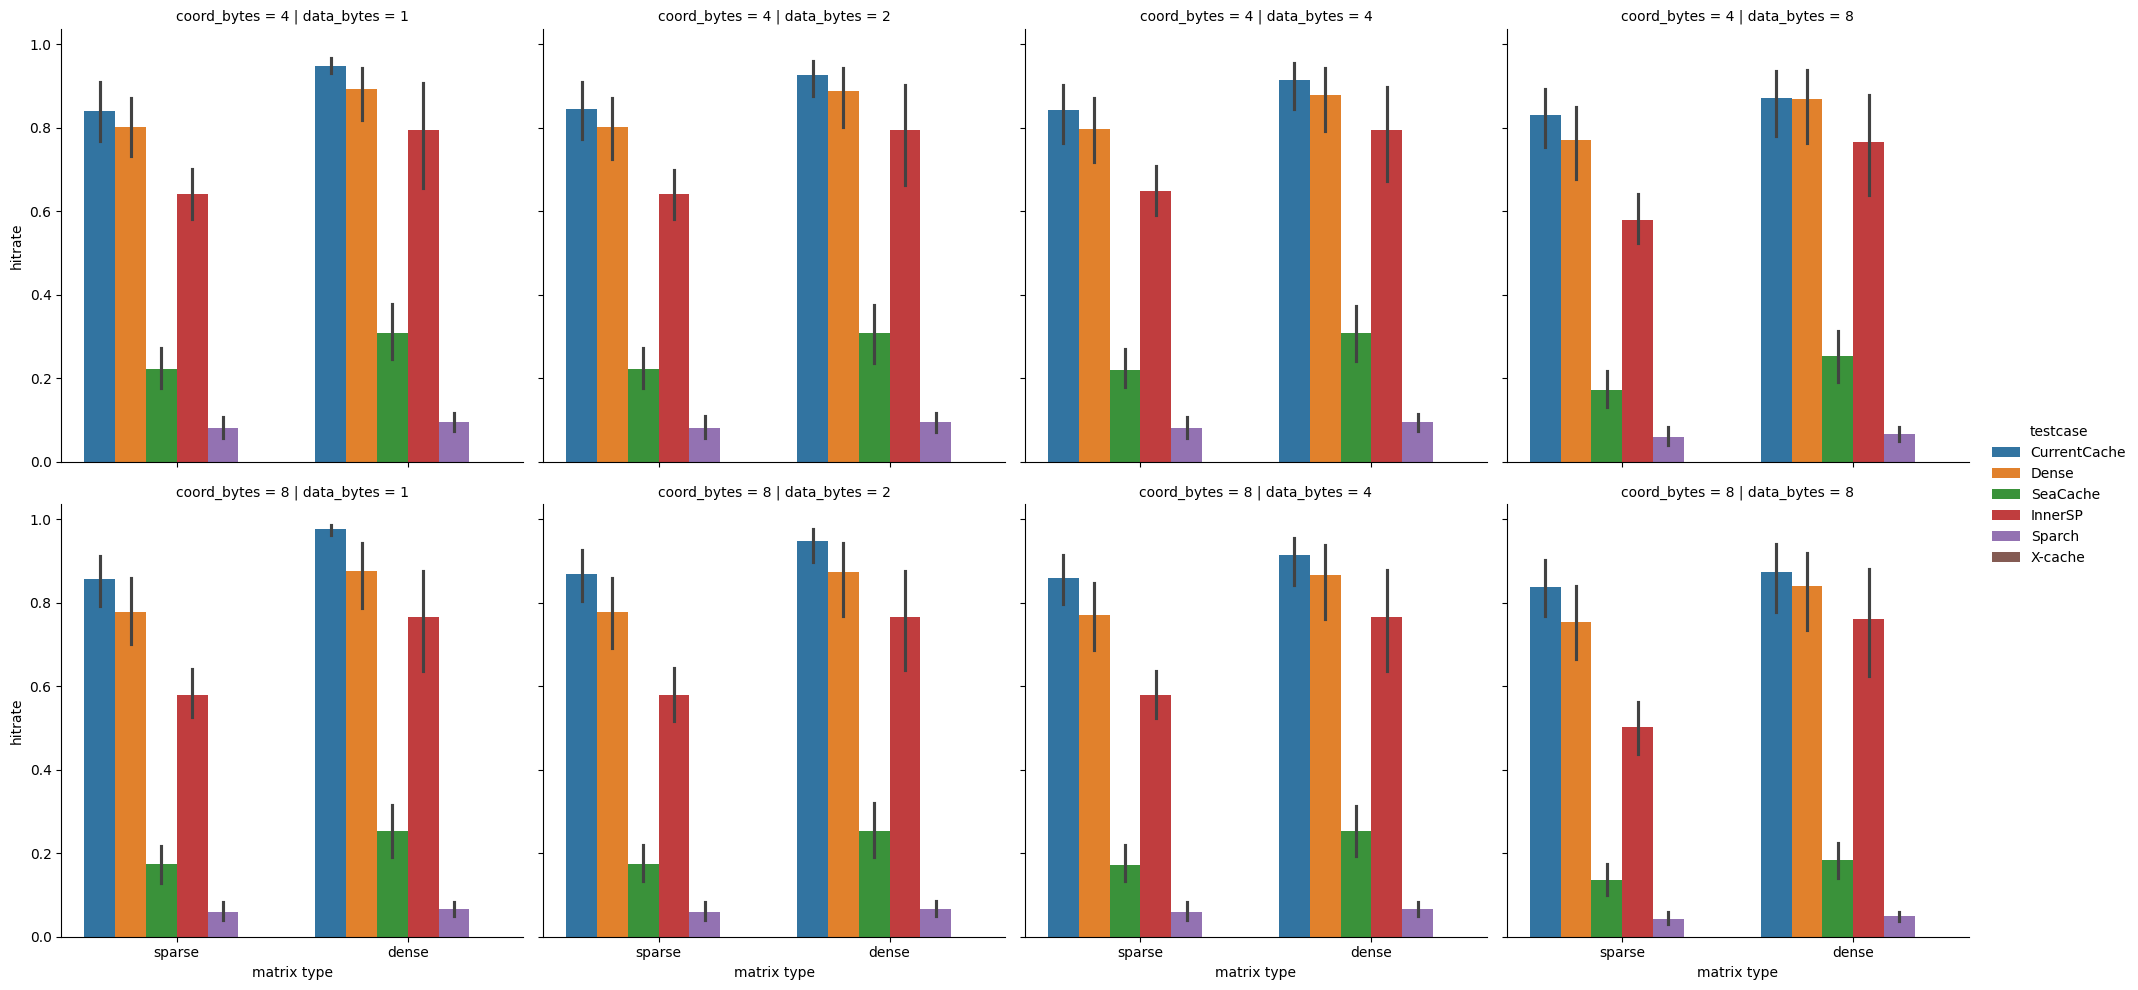

In [62]:
sns.catplot(data=data, col='data_bytes', row='coord_bytes', y='hitrate', hue='testcase', kind='bar', x='matrix type')
plt.savefig('../renderings/hitrate.png')

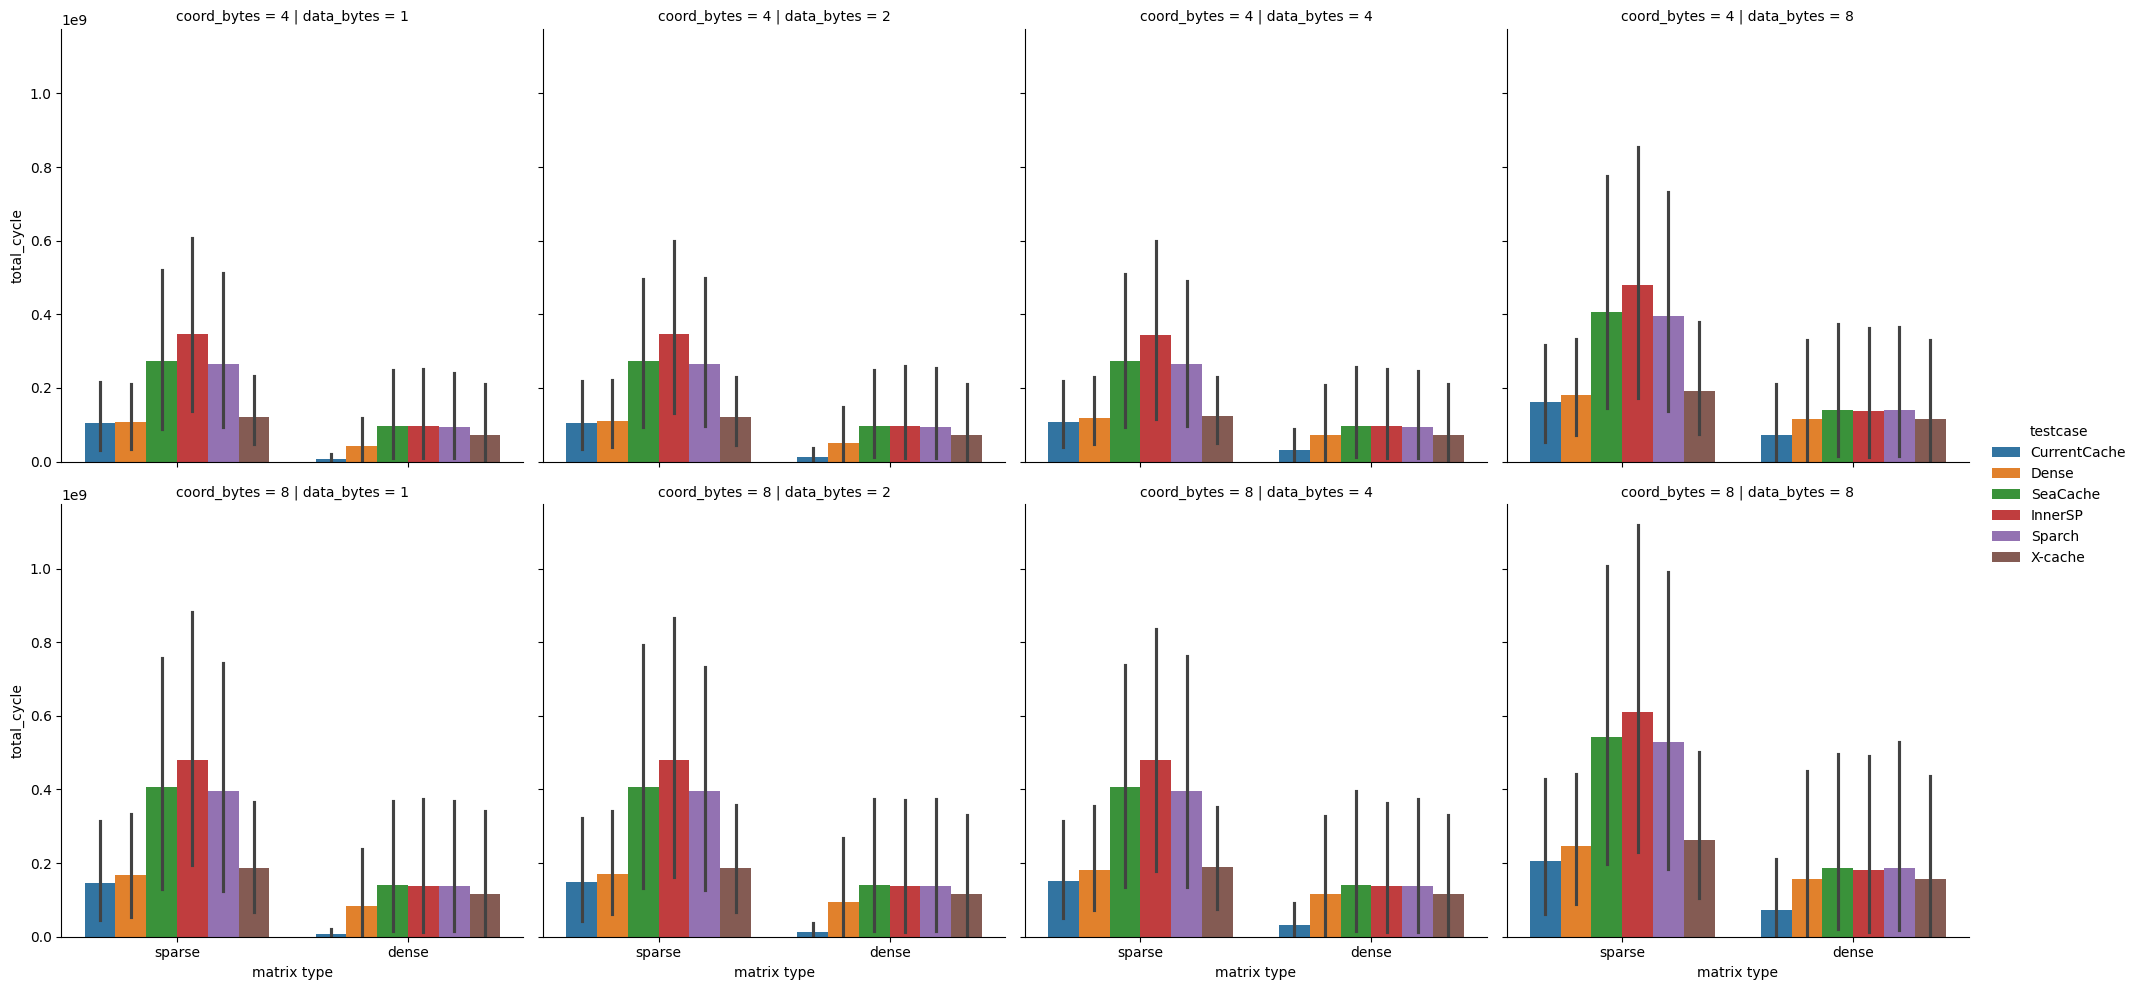

In [63]:
sns.catplot(data=data, col='data_bytes', row='coord_bytes', y='total_cycle', hue='testcase', kind='bar', x='matrix type')

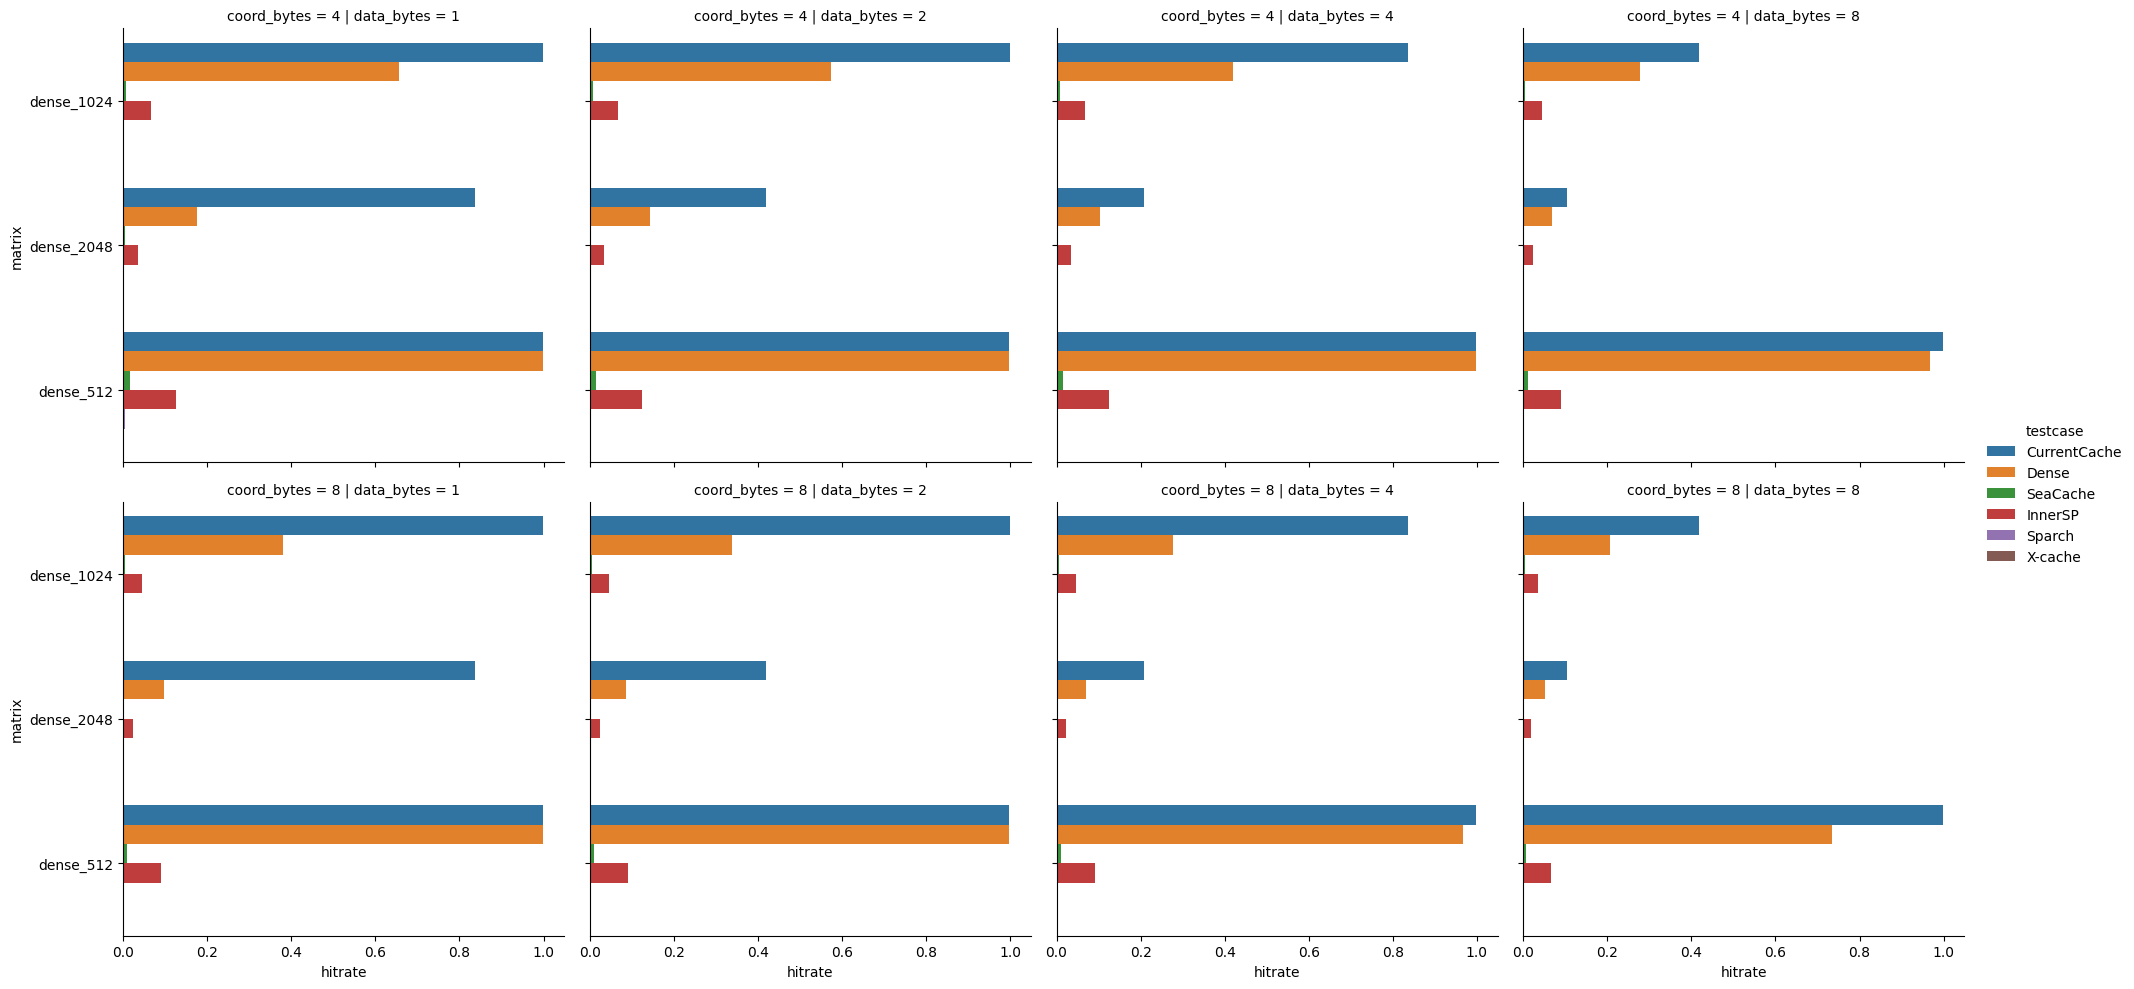

In [64]:
mask = data['matrix'].str.contains('dense_1024') | data['matrix'].str.contains('dense_512') | data['matrix'].str.contains('dense_2048')
sns.catplot(data=data.loc[mask], x='hitrate', y='matrix', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes')
plt.savefig('../renderings/dense_sweep.png')

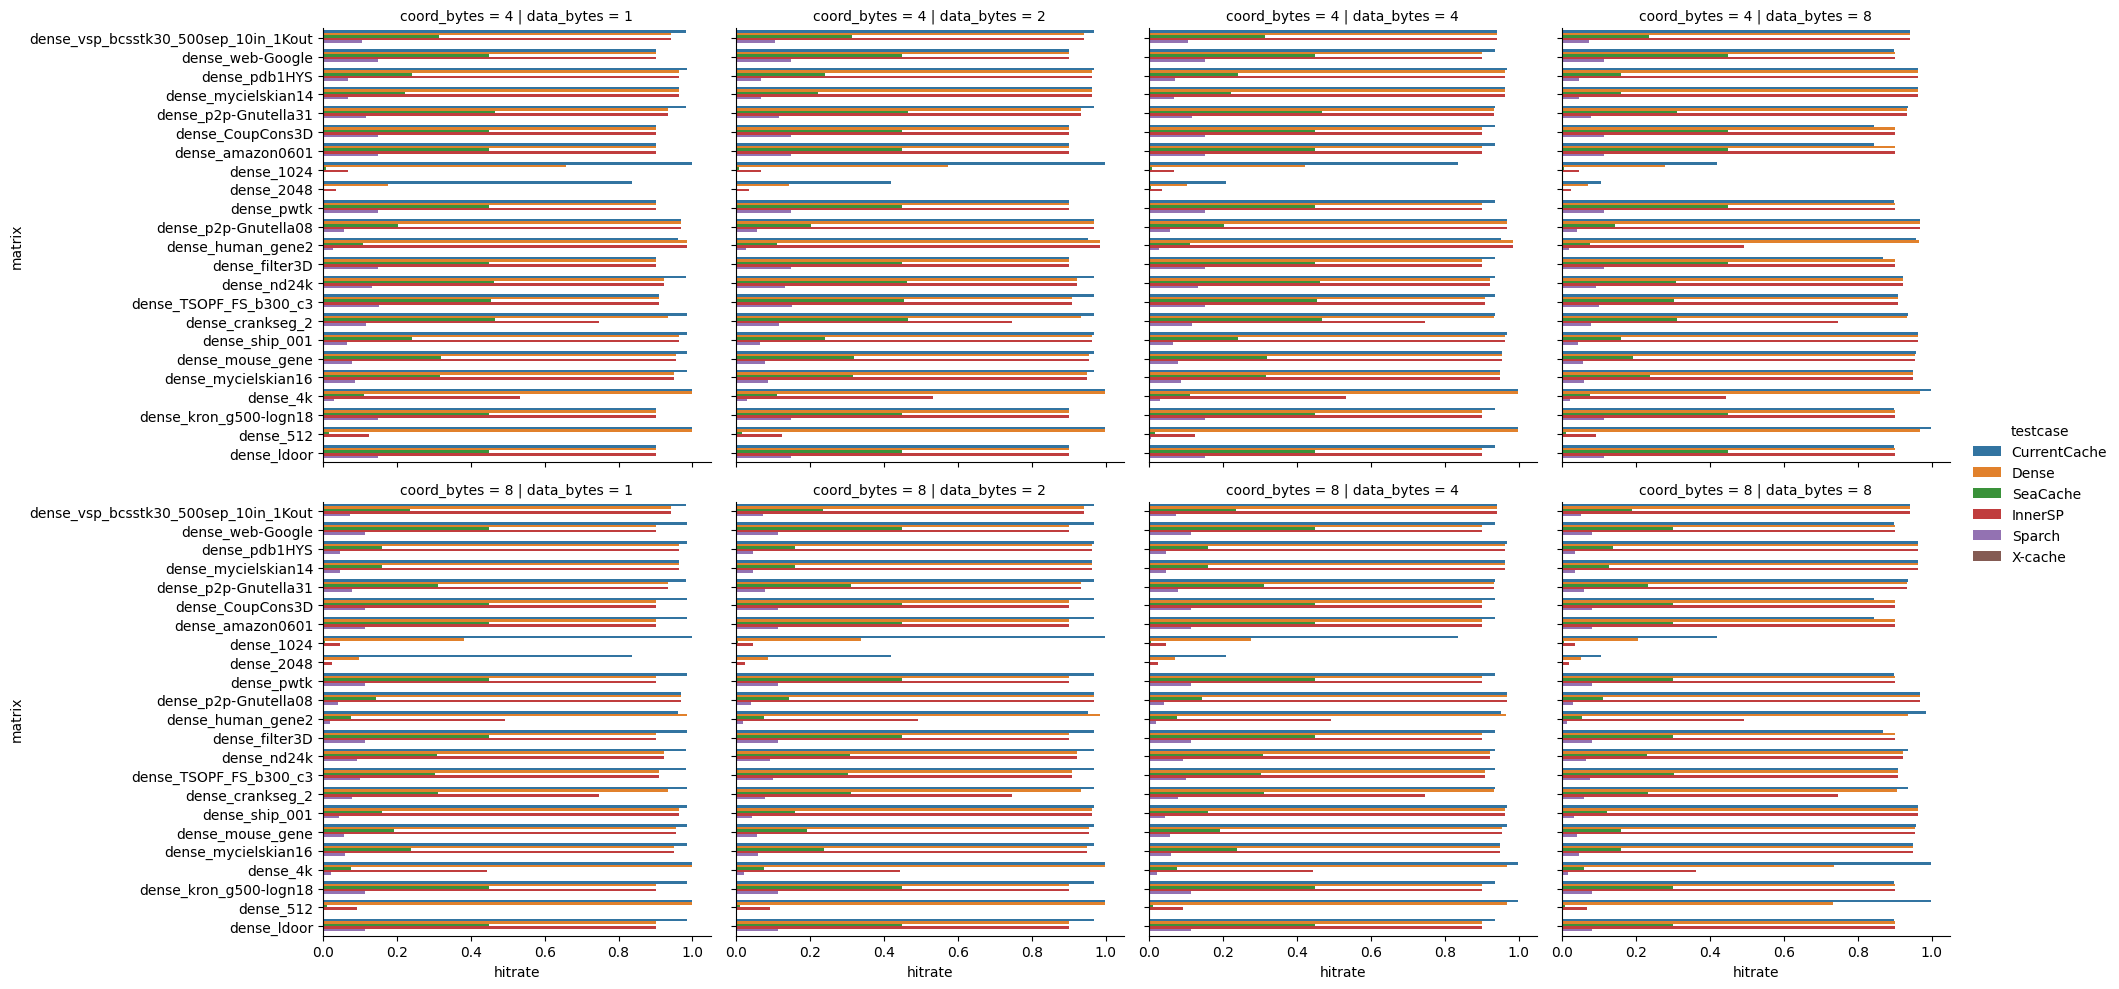

In [65]:
mask = data['matrix'].str.contains('dense')
sns.catplot(data=data.loc[mask], x='hitrate', y='matrix', hue='testcase', orient='h', aspect=1, height=5, kind='bar', row='coord_bytes', col='data_bytes')
plt.savefig('../renderings/full_dense_sweep.png')

In [66]:
data['normalized_cyc'] = 0.
mask = data.testcase == 'SeaCache'
compare_point = data.loc[mask].set_index('matrix').total_cycle
for testcase in data['testcase'].unique():
    mask = data.testcase == testcase
    tmp = compare_point / data.loc[mask].set_index('matrix').total_cycle
    data.loc[mask, 'normalized_cyc'] = tmp.values


ValueError: Must have equal len keys and value when setting with an iterable

In [ ]:
sns.catplot(data=data, col='data_bytes', row='coord_bytes', y='normalized_cyc', hue='testcase', kind='bar', x='matrix type').set_ylabels('Speedup')
plt.savefig('../renderings/relative_cycles.png')

In [ ]:
bert = data['matrix'].str.contains('bert')
gpt = data['matrix'].str.contains('gpt')
long = data['matrix'].str.contains('longformer')
data['kind'] = 'general'
data.loc[bert, 'kind'] = 'bert'
data.loc[gpt, 'kind'] = 'gpt'
data.loc[long, 'kind'] = 'longformer'
fig = sns.catplot(data=data.loc[bert | gpt | long], x='normalized_cyc', y='kind', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes').set_xlabels('Speedup')
plt.savefig('../renderings/llm_sweep_speedup.png')

In [ ]:
fig = sns.catplot(data=data.loc[bert | gpt | long], x='hitrate', y='kind', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes').set_xlabels('Hitrate')
plt.savefig('../renderings/llm_sweep_hitrate.png')

In [ ]:
fig = sns.catplot(data=data.loc[bert | gpt | long], x='dense_hitrate', y='kind', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes').set_xlabels('Hitrate')
plt.savefig('../renderings/llm_sweep_dense_hitrate.png')

In [ ]:
fig = sns.catplot(data=data.loc[bert | gpt | long], x='dense_stores', y='kind', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes').set_xlabels('dense stores')
plt.savefig('../renderings/llm_sweep_dense_stores.png')

In [ ]:
fig = sns.catplot(data=data.loc[bert | gpt | long], x='dense_stores_hit', y='kind', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes').set_xlabels('Hitrate')
plt.savefig('../renderings/llm_sweep_dense_stores_hit.png')

In [ ]:
data['sparse_replaced_dense_normalized'] = data['sparse_replaced_dense'] / data['total_sram_cycle']
data['dense_replaced_sparse_normalized'] = data['dense_replaced_sparse'] / data['total_sram_cycle']
data['dense_stores_normalized'] = data['dense_stores'] / data['total_sram_cycle']

In [ ]:
fig = sns.relplot(data=data.loc[data.testcase == 'CurrentCache'], x='dense_stores_normalized', y='normalized_cyc', hue='matrix type')

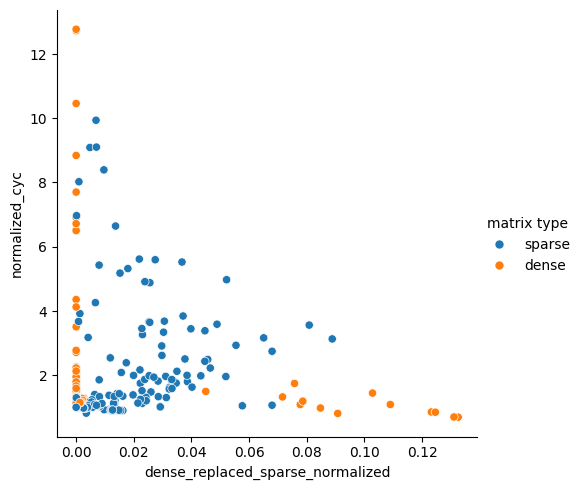

In [47]:
fig = sns.relplot(data=data.loc[data.testcase == 'CurrentCache'], x='dense_replaced_sparse_normalized', y='normalized_cyc', hue='matrix type')


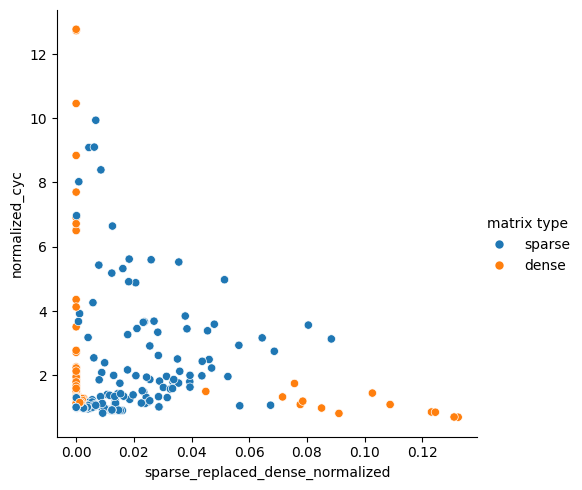

In [48]:
fig = sns.relplot(data=data.loc[data.testcase == 'CurrentCache'], x='sparse_replaced_dense_normalized', y='normalized_cyc', hue='matrix type')


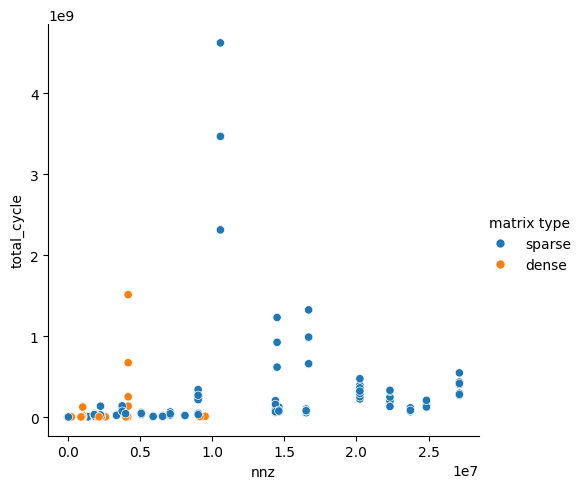

In [67]:
fig = sns.relplot(data=data.loc[data.testcase == 'CurrentCache'], x='nnz', y='total_cycle', hue='matrix type')


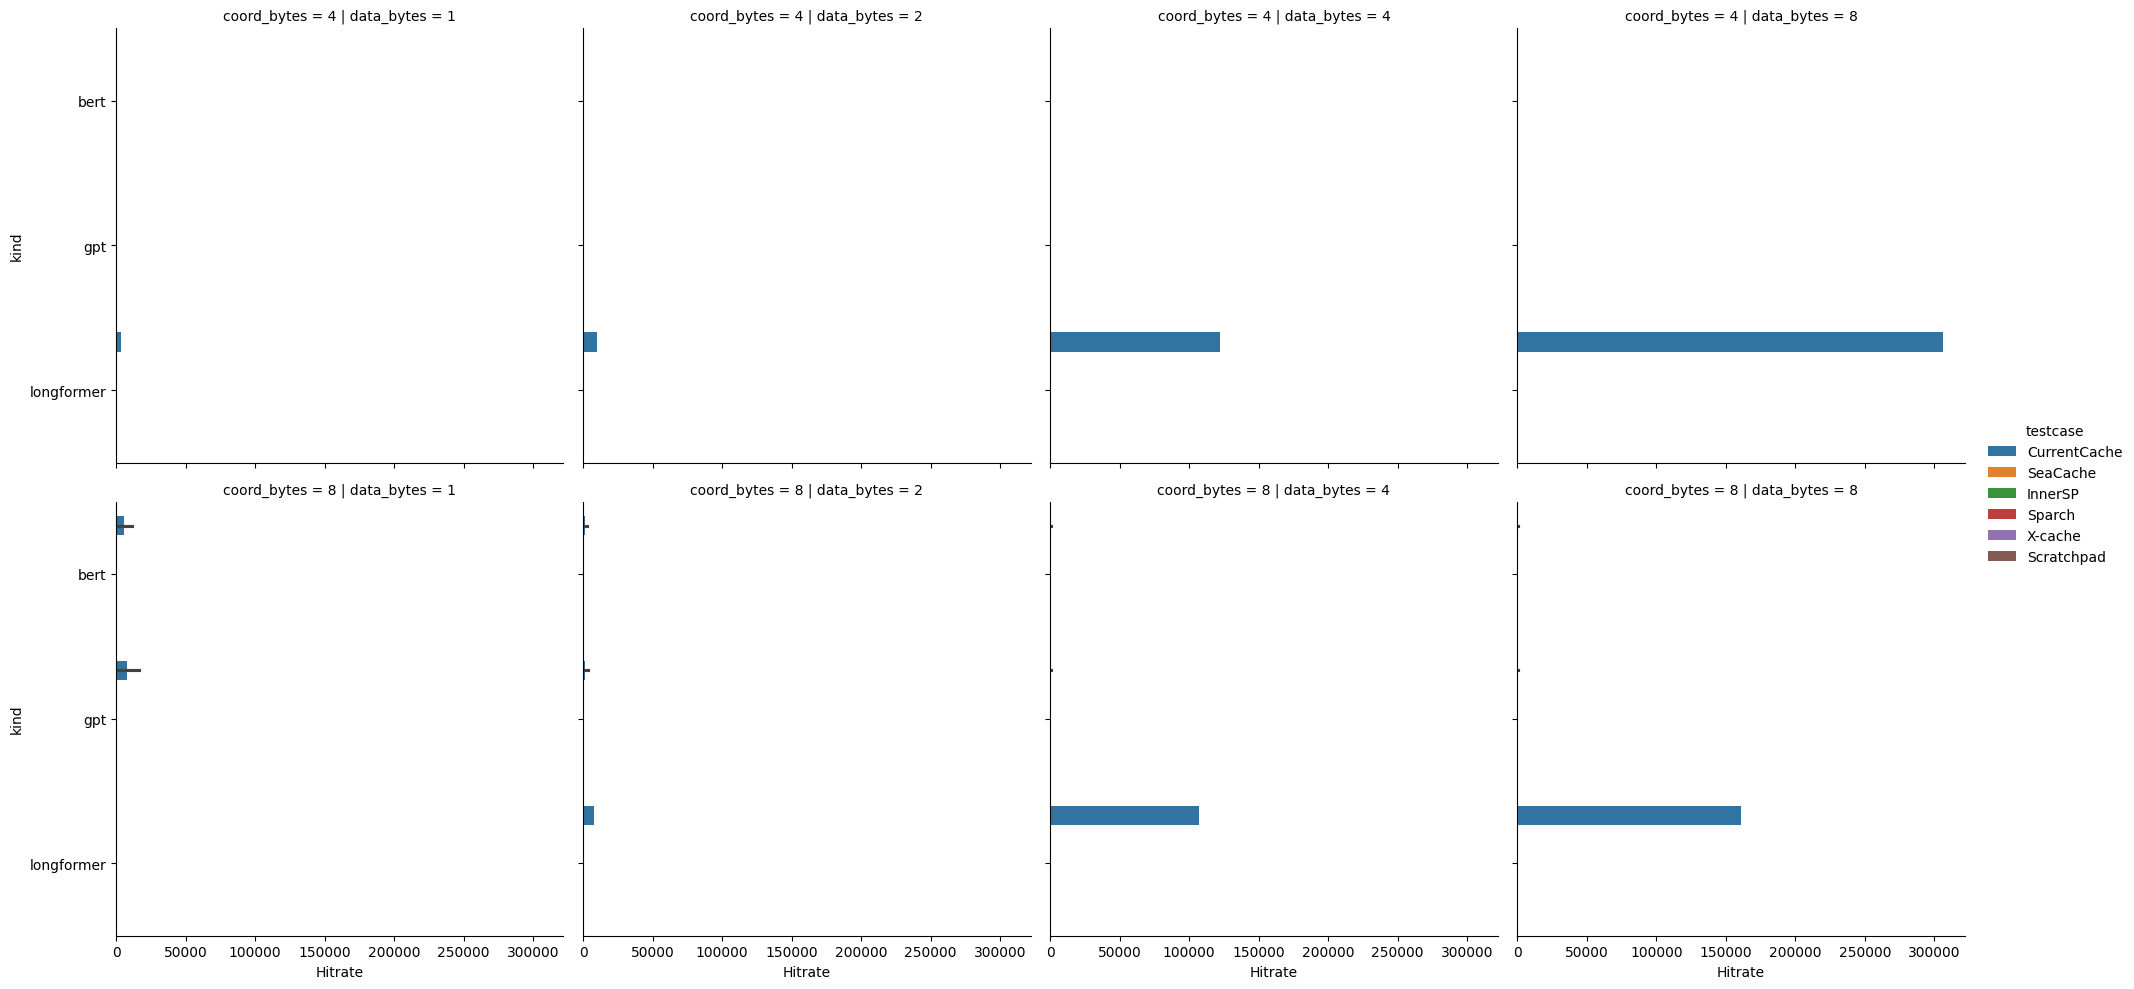

In [50]:
fig = sns.catplot(data=data.loc[bert | gpt | long], x='dense_replaced_sparse', y='kind', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes').set_xlabels('Hitrate')

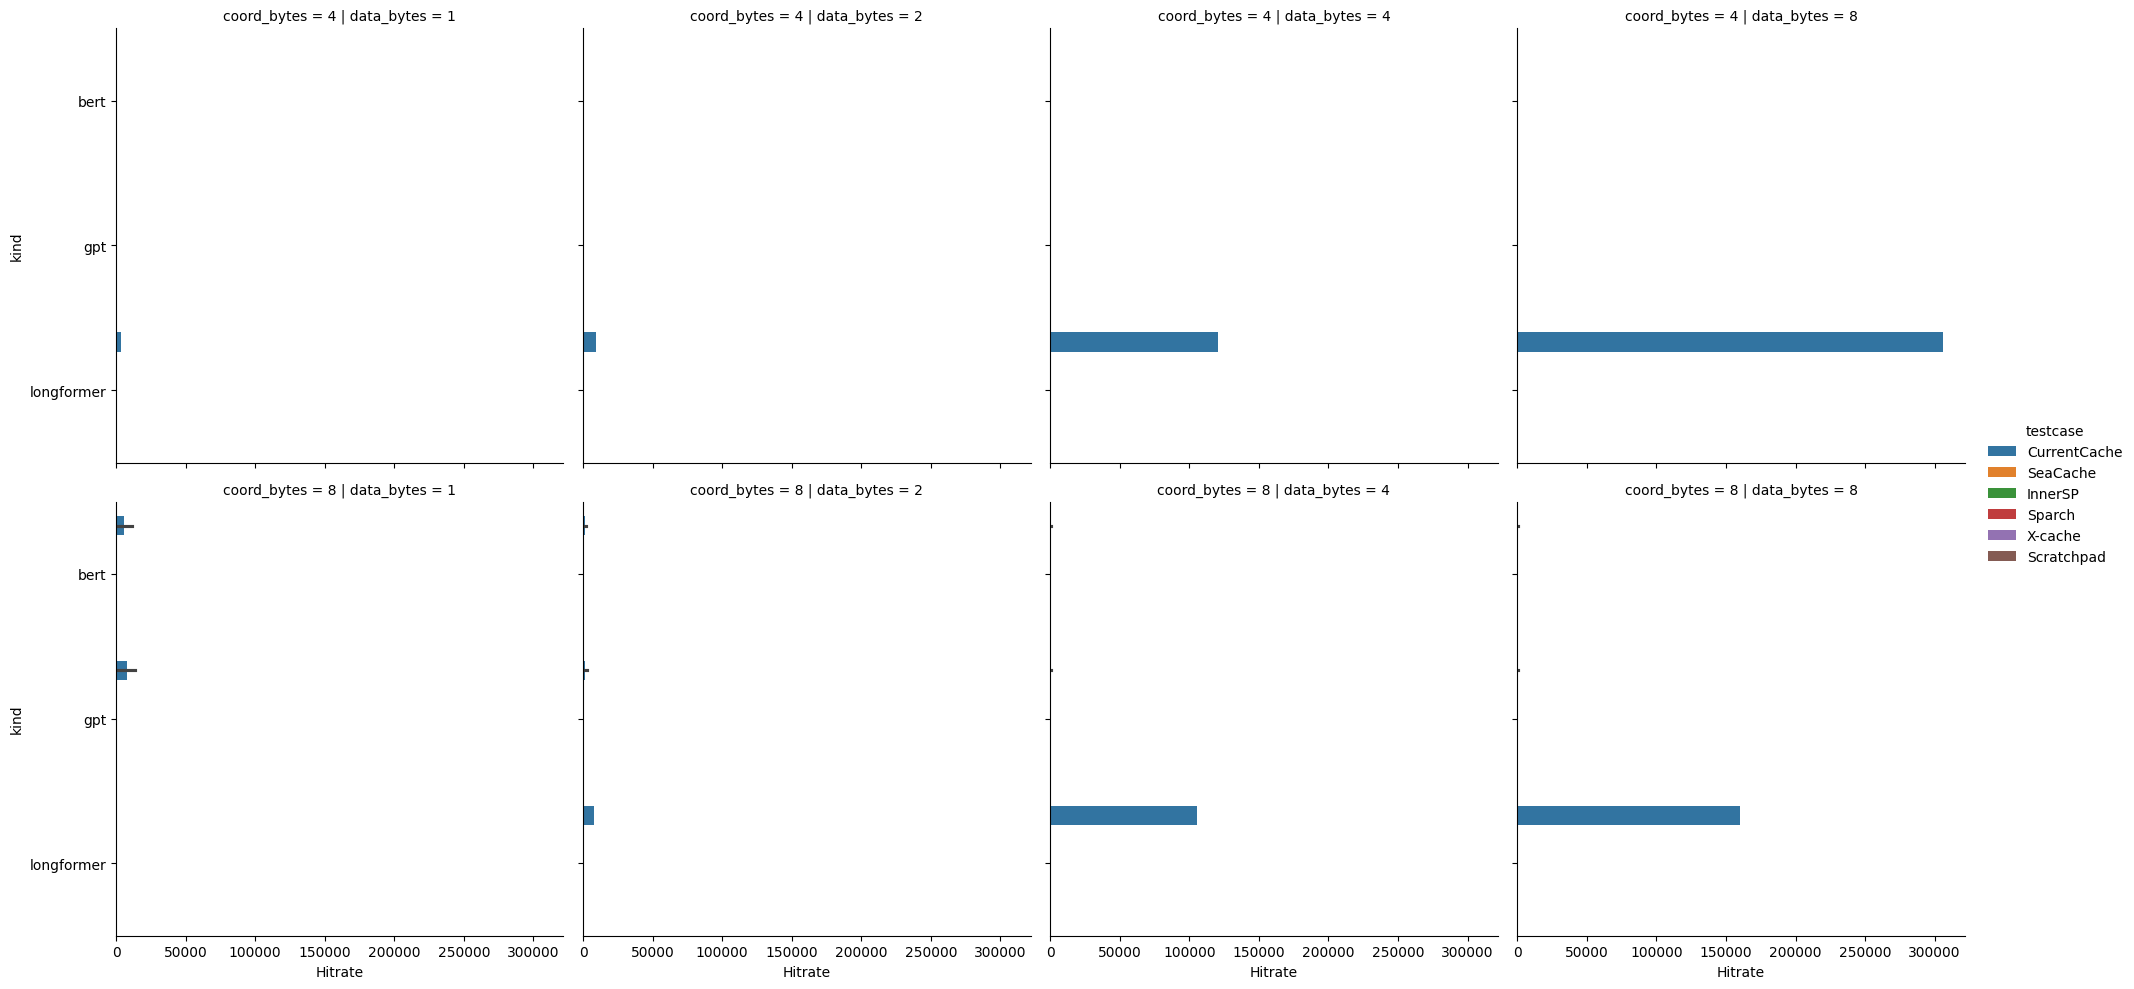

In [51]:
fig = sns.catplot(data=data.loc[bert | gpt | long], x='sparse_replaced_dense', y='kind', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes').set_xlabels('Hitrate')

In [52]:
data_dir = "../output_sweep/"
sweep_files = os.listdir(data_dir)
sweep_data, _ = parse_runs(sweep_files)
sweep_data['tile'] = sweep_data.file.str.split('_').str[0].str.split('.').str[0]
sweep_data.head()

,total_cycle,load_cycle,multiply_cycle,merge_writeback_cycle,total_sram_cycle,total_dram_cycle,total_pe_cycle,total_dram_access_a,total_dram_access_b,total_dram_access_c,...,dense_replaced_sparse,sparse_replaced_dense,file,testcase,nnz,I,J,K,non_empty,tile
0,17636208,36720,16777216,822272,8795648,1935168,16777216,714452,435200,1644544,...,0,0,256.txt,CurrentCache,1048576,1024,1024,1024,1.000000,256
1,65514230,36720,64655238,822272,22582773,64655238,16777216,714452,63155256,1644544,...,0,0,256.txt,SeaCache,1048576,1024,1024,1024,1.000000,256
2,220117552,36720,219258560,822272,36721664,219258560,16777216,1392184,217080832,1644544,...,0,0,256.txt,InnerSP,1048576,1024,1024,1024,1.000000,256
3,239371696,36720,238512704,822272,52293120,238512704,16777216,714452,237012736,1644544,...,0,0,256.txt,Sparch,1048576,1024,1024,1024,1.000000,256
4,214505392,36720,213646400,822272,34318336,213646400,16777216,714452,212146432,1644544,...,0,0,256.txt,X-cache,1048576,1024,1024,1024,1.000000,256


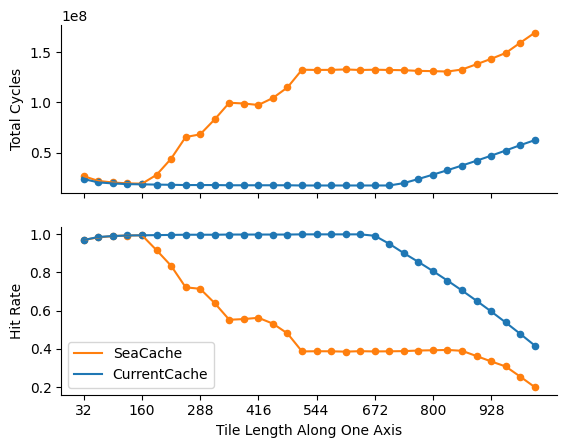

In [53]:
mask = (sweep_data.testcase == 'SeaCache') | (sweep_data.testcase == 'CurrentCache')
scache_currentcache = sweep_data.loc[mask, ['hitrate', 'total_cycle', 'testcase', 'tile']]

numeric_cols = [col for col in scache_currentcache.columns if 'file' not in col and 'testcase' not in col and 'mode' not in col and 'matrix' not in col]
for col in numeric_cols:
    scache_currentcache[col] = pd.to_numeric(scache_currentcache[col], errors='coerce')
scache_currentcache = scache_currentcache.set_index(['testcase','tile']).sort_index(level=1)

fig, (ax0, ax1) = plt.subplots(2, sharex=True)
for grp, color in zip(['SeaCache', 'CurrentCache'], ['tab:orange', 'tab:blue']):
    data = scache_currentcache.loc[(grp, slice(None)), :].reset_index(level=1, drop=False)
    data.plot(x='tile', y='hitrate', ax=ax1, label=grp, color=color)
    data.plot(x='tile', y='hitrate', ax=ax1, kind='scatter', label=None, color=color)

    data.plot(x='tile', y='total_cycle', ax=ax0, label=grp, color=color)
    data.plot(x='tile', y='total_cycle', ax=ax0, kind='scatter', label=None, color=color)


sns.despine(fig)
# sns.despine(ax=ax0, bottom=True)
ax0.set_xticks([], minor=True)
ax1.set_xticks(ticks=data.tile[::4])

ax0.set_xlabel('')
ax1.set_xlabel('Tile Length Along One Axis')

ax0.set_ylabel('Total Cycles')
ax1.set_ylabel('Hit Rate')

ax0.get_legend().remove()

# ax0.set_title('Sweep of Tile Size on Dense 1024x1024 Matrix')

plt.savefig('../renderings/dense_tile_sweep.png')